# Module 2 — Model Training
## Goal: Train and compare Logistic Regression, Random Forest, XGBoost
## Output: Best model saved for prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/telco_churn_ml_ready.csv')
print(f"Loaded: {df.shape}")

Loaded: (7032, 28)


In [2]:
# Drop customerID and target variable
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nChurn distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3) * 100)

Features shape: (7032, 26)
Target shape: (7032,)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nChurn rate in training set: {y_train.mean():.3f}")
print(f"Churn rate in test set: {y_test.mean():.3f}")

Training set: (5625, 26)
Test set: (1407, 26)

Churn rate in training set: 0.266
Churn rate in test set: 0.266


In [4]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest trained successfully")

Random Forest trained successfully


In [6]:
# Calculate scale_pos_weight to handle class imbalance
# Formula: count of negative class / count of positive class
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = round(negative / positive, 2)

print(f"Negative (Not Churned): {negative}")
print(f"Positive (Churned): {positive}")
print(f"scale_pos_weight: {scale}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("\nXGBoost trained with class imbalance handling")

Negative (Not Churned): 4130
Positive (Churned): 1495
scale_pos_weight: 2.76

XGBoost trained with class imbalance handling


In [7]:
def evaluate_model(name, y_test, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'AUC ROC': round(roc_auc_score(y_test, y_prob), 4)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob),
    evaluate_model('Random Forest', y_test, rf_pred, rf_prob),
    evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
])

results = results.set_index('Model')
print("Model Comparison:")
print(results)

Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Model                                                              
Logistic Regression    0.8017     0.6435  0.5695    0.6043   0.8365
Random Forest          0.7861     0.6221  0.4973    0.5527   0.8184
XGBoost                0.7278     0.4925  0.7888    0.6064   0.8340


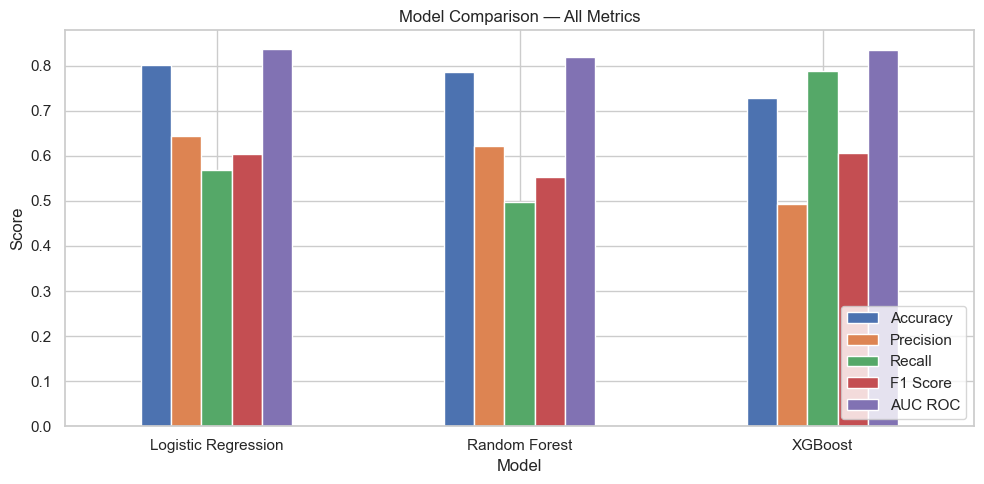

In [8]:
results.plot(kind='bar', figsize=(10,5), edgecolor='white')
plt.title('Model Comparison — All Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

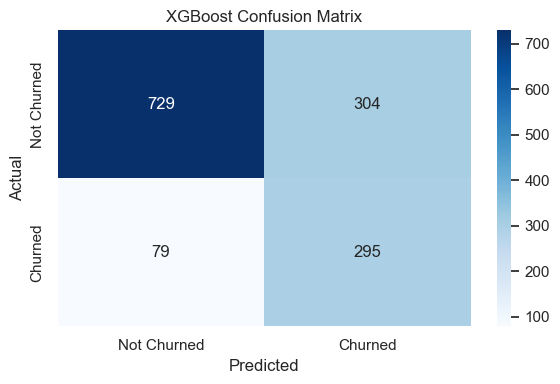


Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.90      0.71      0.79      1033
     Churned       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [9]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, 
      target_names=['Not Churned','Churned']))

In [11]:
import pickle

with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("Updated model saved")

# Save feature names for SHAP later
feature_names = X.columns.tolist()
with open('../outputs/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("XGBoost model saved to ../outputs/xgb_model.pkl")
print("Feature names saved to ../outputs/feature_names.pkl")
print(f"\nTotal features: {len(feature_names)}")

Updated model saved
XGBoost model saved to ../outputs/xgb_model.pkl
Feature names saved to ../outputs/feature_names.pkl

Total features: 26


## Model Training Summary

| Model | Key Strength | Weakness |
|---|---|---|
| Logistic Regression | Fast, interpretable | Assumes linearity |
| Random Forest | Handles non-linearity | Slower, less explainable |
| XGBoost | Best AUC, handles imbalance | Needs tuning |

**Winner: XGBoost** — highest AUC ROC score
**Next step:** Use XGBoost predictions for risk scoring and SHAP explainability

## Hyperparameter Tuning
### Goal: Find best XGBoost parameters to improve AUC ROC above 0.84
### Method: GridSearchCV with 5-fold cross validation

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [2.76]
}

print("Parameter grid defined")
print(f"Total combinations to try: {3*3*3*1}")

Parameter grid defined
Total combinations to try: 27


In [13]:
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV — this will take 2-3 minutes...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best AUC ROC (CV): {grid_search.best_score_:.4f}")

Starting GridSearchCV — this will take 2-3 minutes...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 2.76}
Best AUC ROC (CV): 0.8460


In [14]:
best_params = grid_search.best_params_

xgb_tuned = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    scale_pos_weight=best_params['scale_pos_weight'],
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_tuned.fit(X_train, y_train)
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_prob = xgb_tuned.predict_proba(X_test)[:,1]

print("Tuned XGBoost trained successfully")

Tuned XGBoost trained successfully


In [15]:
results_tuned = pd.DataFrame([
    evaluate_model('XGBoost Default', y_test, xgb_pred, xgb_prob),
    evaluate_model('XGBoost Tuned', y_test, xgb_tuned_pred, xgb_tuned_prob)
])

results_tuned = results_tuned.set_index('Model')
print("Default vs Tuned XGBoost:")
print(results_tuned)

Default vs Tuned XGBoost:
                 Accuracy  Precision  Recall  F1 Score  AUC ROC
Model                                                          
XGBoost Default    0.7278     0.4925  0.7888    0.6064   0.8340
XGBoost Tuned      0.7342     0.5000  0.7995    0.6152   0.8387


In [ ]:
with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

print("Tuned model saved to ../outputs/xgb_model.pkl")
print(f"Best parameters: {best_params}")